# Understanding Tidal Hydrodynamic Models
## A gentle introduction — no physics degree required

This notebook explains what a **hydrodynamic model** is, why we build one, and
how each piece works.  We start from first principles, use plain language,
and only introduce equations once the idea is clear.

### What you'll learn

1.  **What are tides and why do they matter?**
2.  **How do we represent the ocean inside a computer?**  (the grid)
3.  **How do we describe moving water with numbers?**  (the equations, gently)
4.  **Where does the seafloor shape come from?**  (bathymetry)
5.  **How do we tell the model where the land is?**  (land masking)
6.  **How do tides enter the model?**  (boundary conditions)
7.  **How does the model march forward in time?**  (time-stepping)
8.  **What limits how fast we can run?**  (stability)
9.  **Running a real simulation and seeing the results**

### Prerequisites

You only need basic Python.  Every concept is explained before any code runs.
If you see an equation, read the text *before* it — the text gives you the
intuition; the equation is just the precise version of that intuition.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")

import numpy as np
import xarray as xr
import yaml
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

---
## Part 1 — What Are We Actually Modelling?

### The big picture

Imagine you are standing on a beach.  The water level rises and falls twice a
day — that's the **tide**.  At the same time, water is moving horizontally:
**tidal currents** push water in and out of bays, through narrow straits, and
around islands.

A **hydrodynamic model** is a computer program that simulates this behaviour.
Given the shape of the seafloor and the tides at the edges of our region, the
model predicts how water moves *everywhere inside* the region.

### Why the Philippines?

The Philippines is an archipelago of 7 000+ islands sitting in some of the
strongest tidal currents on Earth.  Narrow passages between islands act like
funnels, accelerating water to several metres per second — perfect for
extracting **tidal-stream energy**.

But before we can decide *where* to put turbines, we need to know *where the
fastest currents are*.  That's what this model does: it screens the entire
country and finds the energetic hotspots.

### What causes tides?

Tides are caused by the gravitational pull of the **Moon** and the **Sun**.
The Moon pulls the ocean toward it, creating a bulge of water.  Because the
Earth rotates, most places see two high tides and two low tides each day.

The Sun also pulls on the ocean, but only about half as strongly.  When the
Sun and Moon line up (new moon and full moon), we get extra-large **spring
tides**.  When they pull at right angles, we get smaller **neap tides**.

| Cause | Period | Name | Relative strength |
|---|---|---|---|
| Moon | 12.42 h | **M₂** | 100% (dominant) |
| Sun  | 12.00 h | **S₂** | ~47% |
| Moon + Sun declination | 23.93 h | **K₁** | ~58% |
| Moon declination | 25.82 h | **O₁** | ~42% |

Each row is a **tidal constituent** — a pure sine wave with a known frequency.
The real tide is the *sum* of these waves.  (The astronomical symbols like M₂
are just labels that oceanographers use — M for Moon, S for Sun, 2 for
twice-daily.)

---
## Part 2 — The Grid: Turning the Ocean into a Spreadsheet

### Why we need a grid

The ocean is continuous — water can exist at every point.  But a computer
can't store an infinite number of points.  So we **discretise**: we cover the
region with a mesh of squares, like a giant spreadsheet laid over the ocean.

Each cell in the spreadsheet stores numbers:
- **Water depth** (how deep is the seafloor here?)
- **Surface elevation** (how high is the water above its average level?)
- **Current speed** (how fast is the water moving, and in which direction?)

The model's job is to update these numbers for every cell, every few seconds,
to simulate how the ocean evolves over days or weeks.

### Grid resolution — a trade-off

Smaller cells = more detail, but more cells to compute.

| Cell size | Cells covering the Philippines | Compute time |
|---|---|---|
| 10 km | ~1 500 | seconds |
| 2 km  | ~90 000 | minutes |
| 200 m | ~9 000 000 | hours/days |

Our default is **2 km** — fine enough to resolve the channels between islands
where tidal energy concentrates, but coarse enough to run in reasonable time.

### The Arakawa C-grid — a clever arrangement

Imagine a chessboard.  In the simplest approach, you'd put water height *and*
velocity at the centre of every square.  This seems natural, but it causes a
numerical problem called **checkerboarding** — neighbouring cells can develop
high-low-high-low patterns that look valid but are physically impossible.

The **Arakawa C-grid** solves this by *staggering* the variables:

- **Water height** (η) and **depth** (h) live at the centre of each cell 🔵
- **East–west velocity** (u) lives on the left/right faces of each cell ▶
- **North–south velocity** (v) lives on the top/bottom faces of each cell ▼

```
       v[j+1,i]
  +-------▼-------+       🔵  η, h  at cell centre (j, i)
  |               |       ▶  u     at east face   (j, i+½)
  |   🔵 η[j,i]   |       ▼  v     at north face  (j+½, i)
  |   h[j,i]  ----▶ u[j,i+1]
  |               |
  +-------▼-------+
       v[j,i]
```

**Why this is clever:** when water flows into a cell from the left, the
velocity is already stored at the left face — no interpolation needed.
When water height changes, the pressure difference between two adjacent
cells drives flow through the face between them.  Everything lines up
naturally.

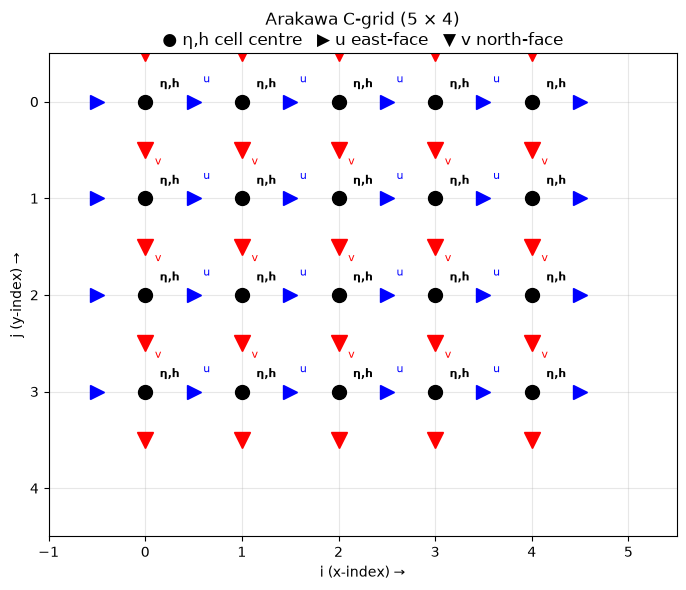

In [2]:
from model.grid import StructuredGrid

grid = StructuredGrid.from_uniform(nx=5, ny=4, dx=1000.0, dy=1000.0, lat0=12.5)

fig, ax = plt.subplots(figsize=(8, 6))
ny, nx = grid.shape

for j in range(ny):
    for i in range(nx):
        ax.plot(i, j, "ko", markersize=10, zorder=3)
        ax.text(i + 0.15, j - 0.15, "η,h", fontsize=8, color="black", fontweight="bold")

for j in range(ny):
    for i in range(nx + 1):
        ax.plot(i - 0.5, j, "b>", markersize=10, zorder=2)
        if i > 0 and i < nx:
            ax.text(i - 0.5 + 0.1, j - 0.2, "u", fontsize=8, color="blue")

for j in range(ny + 1):
    for i in range(nx):
        ax.plot(i, j - 0.5, "rv", markersize=12, zorder=2)
        if j > 0 and j < ny:
            ax.text(i + 0.1, j - 0.5 + 0.15, "v", fontsize=8, color="red")

ax.set_xlim(-1, nx + 0.5)
ax.set_ylim(-0.5, ny + 0.5)
ax.set_aspect("equal")
ax.set_xlabel("i (x-index) →")
ax.set_ylabel("j (y-index) →")
ax.set_title("Arakawa C-grid (5 × 4)\n● η,h cell centre   ▶ u east-face   ▼ v north-face",
             fontsize=12)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Part 3 — The Equations: Rules That Water Follows

Water obeys two physical laws:

### Rule 1: Conservation of mass (continuity)

> *You cannot create or destroy water.*

If more water flows into a cell than flows out, the water level in that cell
must rise.  If more flows out than in, the level drops.  That's it.

```
   Inflow from left ──▶ ┌─────────┐ ──▶ Outflow to right
                        │  Cell   │
   Inflow from below ──▶ │  η, h   │ ──▶ Outflow to top
                        └─────────┘

   Change in η  =  (Flow_in  − Flow_out)  /  cell_area
```

### Rule 2: Newton's second law (momentum)

> *Force = mass × acceleration.*

Water accelerates when pushed.  What pushes it?

| Force | What causes it | Effect |
|---|---|---|
| **Pressure gradient** | Water is higher in one cell than its neighbour | Water flows downhill, from high to low |
| **Coriolis** | Earth's rotation | Deflects flow to the right (N hemisphere) |
| **Bottom friction** | Water rubs against the seafloor | Slows the flow, especially in shallow water |
| **Advection** | Water carries its own momentum | Fast flow stays fast where it's going |

### The pressure gradient — an analogy

Tilt a dinner plate with a puddle of water on it.  The water runs downhill —
from the high side to the low side.  The steeper the tilt, the faster it runs.

The ocean works the same way.  When the tide raises water at one end of a
channel, the water surface tilts.  Water rushes from the high end to the low
end.  This is the **pressure gradient force** — and it's the main driver of
tidal currents.

### The equations (for reference)

*You can skip this cell if equations aren't your thing — the text above tells
you everything you need to know.  The equations are the same ideas written in
mathematical shorthand.*

**Continuity** — the water level changes because of net flow in/out:

$$
\frac{\partial \eta}{\partial t} +
\frac{\partial (h u)}{\partial x} +
\frac{\partial (h v)}{\partial y} = 0
$$

**Momentum (x-direction)** — water accelerates because of forces:

$$
\frac{\partial u}{\partial t} =
\underbrace{-g \frac{\partial \eta}{\partial x}}_{\text{pressure gradient}}
\underbrace{+ f v}_{\text{Coriolis}}
\underbrace{- \frac{C_d}{h} u \sqrt{u^2 + v^2}}_{\text{bottom friction}}
$$

| Symbol | Plain meaning | Units |
|---|---|---|
| $\eta$ | Water surface height above average | metres |
| $h$    | Still-water depth (distance to seafloor) | metres |
| $u$    | East–west current speed | m/s |
| $v$    | North–south current speed | m/s |
| $g$    | Gravity (9.81) | m/s² |
| $f$    | Coriolis (Earth-spin) parameter | rad/s |
| $C_d$  | Bottom-drag coefficient (0.0025) | — |

---
## Part 4 — Bathymetry: The Shape of the Seafloor

### Where does seafloor data come from?

**GEBCO** (General Bathymetric Chart of the Oceans) is a global map of the
seafloor produced by combining ship sonar measurements with satellite gravity
data.  The 2024 version covers the entire planet at 15 arc-second resolution
(~450 m at the equator).

### How GEBCO stores height

GEBCO uses a **positive-up** convention:
- Negative numbers = below sea level (water)
- Positive numbers = above sea level (land)

But our model works with **depth** (positive down), so we flip the sign:
```
depth  =  max( -elevation,  0 )
          └─flip sign─┘  └─land → zero┘
```

### Why depth matters so much

Tidal currents behave very differently in deep vs. shallow water:

| Water depth | Wave speed | Example |
|---|---|---|
| 4 000 m (open ocean) | ~200 m/s (720 km/h) | Philippine Sea |
| 100 m (shelf) | ~31 m/s (113 km/h) | South China Sea shelf |
| 10 m (coastal) | ~10 m/s (36 km/h) | Nearshore channels |

Shallow water slows the tide down.  When a tidal wave enters a narrowing,
shallowing channel, the water piles up and accelerates — exactly where tidal
energy potential is highest.

In [3]:
from model.bathymetry import load_gebco, regrid_bathymetry, elevation_to_depth

with open("../model/config.yaml") as f:
    cfg = yaml.safe_load(f)

REPO_ROOT = Path("../..").resolve()  # src/notebooks -> repository root

domain = cfg["domain"]
bathy_cfg = cfg["bathymetry"]

lon_raw, lat_raw, elev_raw = load_gebco(
    REPO_ROOT / bathy_cfg["path"],
    lon_min=domain["lon_min"], lon_max=domain["lon_max"],
    lat_min=domain["lat_min"], lat_max=domain["lat_max"],
)
lon, lat, elev = regrid_bathymetry(
    lon_raw, lat_raw, elev_raw, resolution_km=domain["resolution_km"]
)
depth = elevation_to_depth(elev)

print(f"Loaded GEBCO:   {elev_raw.shape[0]} × {elev_raw.shape[1]} raw cells")
print(f"Regridded to:   {elev.shape[0]} × {elev.shape[1]} cells at {domain['resolution_km']} km")
print(f"Depth range:    {depth[depth > 0].min():.0f} – {depth.max():.0f} m")
print(f"Land fraction:  {(elev > 0).sum() / elev.size * 100:.1f}%  (Philippine islands)")


Loaded GEBCO:   4320 × 2880 raw cells
Regridded to:   1002 × 668 cells at 2.0 km
Depth range:    0 – 10083 m
Land fraction:  14.4%  (Philippine islands)


---
## Part 5 — Land Masking: Telling the Model "No Water Here"

### Two approaches

The model needs to know which cells are **land** (no computation) and which
are **water** (full physics).  We have two ways to decide:

| Method | How it works | Accuracy |
|---|---|---|
| **GEBCO threshold** | If GEBCO says elevation > 0, it's land | Good at 2 km, misses small islands |
| **GADM shapefile** | Rasterise the official Philippines boundary | Exact administrative coastline |

The shapefile method is preferred because it uses the official surveyed
coastline.  We "burn" the polygon onto the model grid — every cell whose
centre falls inside the polygon is marked as land.

### Water needs a minimum depth

Very shallow cells (less than 2 m) are treated as dry.  This prevents the
model from trying to compute flow in puddles, which would require impossibly
small time steps.

Cells where methods disagree: 0 / 669,336  (0.00%)
→ small differences at the coastline where the shapefile is more accurate


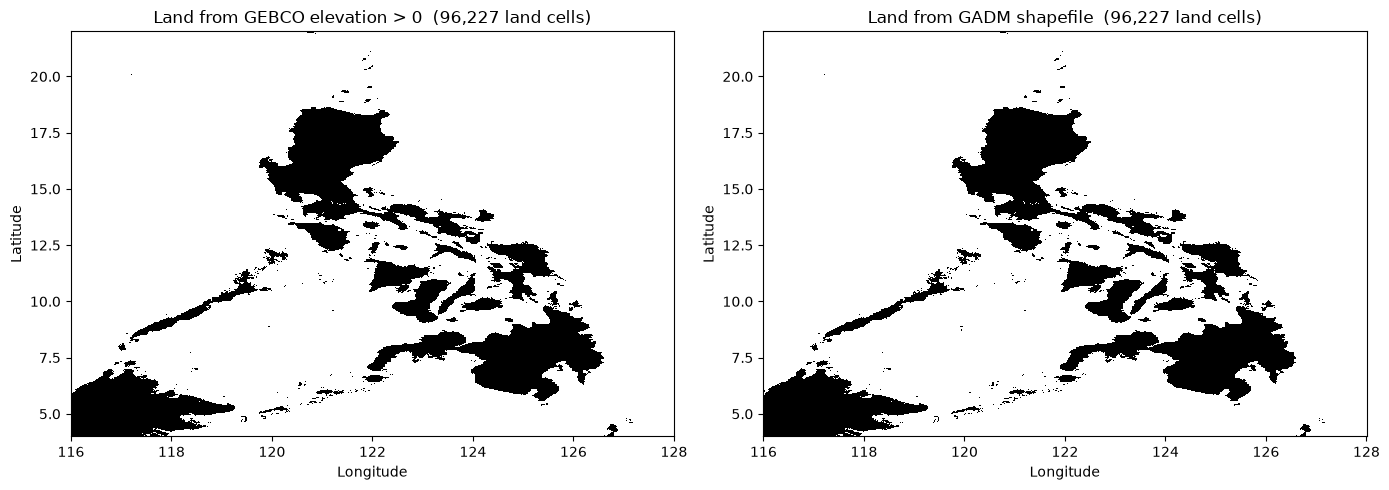

In [4]:
from model.bathymetry import build_land_mask

land_elev = elev > 0.0

shp_path = bathy_cfg.get("land_shapefile")
if shp_path and Path(shp_path).exists():
    land_shp = build_land_mask(lon, lat, shp_path)
else:
    land_shp = land_elev

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.pcolormesh(lon, lat, np.where(land_elev, 0.6, 0), cmap="Greys", shading="auto")
ax.set_title(f"Land from GEBCO elevation > 0  ({land_elev.sum():,} land cells)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

ax = axes[1]
ax.pcolormesh(lon, lat, np.where(land_shp, 0.6, 0), cmap="Greys", shading="auto")
ax.set_title(f"Land from GADM shapefile  ({land_shp.sum():,} land cells)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

diff = land_elev != land_shp
print(f"Cells where methods disagree: {diff.sum():,} / {diff.size:,}  ({diff.sum()/diff.size*100:.2f}%)")
print(f"→ small differences at the coastline where the shapefile is more accurate")
plt.tight_layout()
plt.show()

### Building the grid

`StructuredGrid.from_bathymetry` creates every array the solver needs:

| Array | Shape | Holds |
|---|---|---|
| `h`       | (ny, nx)     | Seafloor depth at each cell centre |
| `mask`    | (ny, nx)     | `True` = water, `False` = land |
| `h_u`     | (ny, nx+1)   | Depth at east–west faces (between cells) |
| `h_v`     | (ny+1, nx)   | Depth at north–south faces |
| `mask_u`  | (ny, nx+1)   | Which u-points have water on both sides |
| `mask_v`  | (ny+1, nx)   | Which v-points have water on both sides |
| `f`       | (ny, nx)     | Coriolis parameter (Earth's spin effect) |
| `open_boundary` | (ny, nx) | Edge cells where the tide enters/exits |

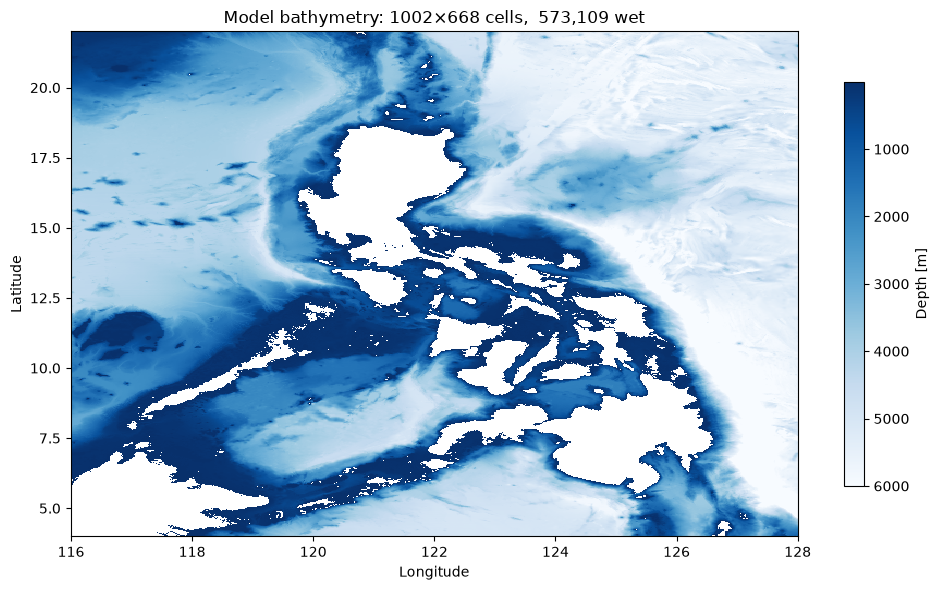

In [5]:
depth_clip = np.clip(depth, bathy_cfg.get("min_depth", 2.0), bathy_cfg.get("max_depth", 6000.0))
grid = StructuredGrid.from_bathymetry(lon, lat, depth_clip, land_mask=land_shp, min_depth=2.0)

fig, ax = plt.subplots(figsize=(10, 6))
h_plot = np.where(grid.mask, grid.h, np.nan)
pc = ax.pcolormesh(grid.lon, grid.lat, h_plot, cmap="Blues_r", shading="auto")
cb = plt.colorbar(pc, ax=ax, label="Depth [m]", shrink=0.8)
cb.ax.invert_yaxis()
ax.set_title(f"Model bathymetry: {grid.shape[0]}×{grid.shape[1]} cells,  {grid.mask.sum():,} wet")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

---
## Part 6 — Tidal Forcing: The Engine That Drives the Model

### The problem: we only model a small region

Our model covers the Philippines, but tides are a *global* phenomenon.
The water moving through our region was set in motion by the Moon's pull
thousands of kilometres away in the Pacific Ocean.

We can't model the whole planet — that would take too long.  Instead, we
**prescribe** the water level at the edges of our domain from a pre-computed
**global tidal model**.  The interior of our domain then responds naturally.

### Global tidal atlases

A global tidal model has already solved the tides for the entire Earth at
coarse resolution.  Several are freely available:

| Model | Resolution | Source | Registration? |
|---|---|---|---|
| **GOT4.10c** | 0.5° (~55 km) | NASA | None — free download |
| **FES2014** | 0.0625° (~7 km) | AVISO (France) | Required |
| **TPXO9** | 0.083° (~9 km) | OSU (USA) | Required |

We use **GOT4.10c** by default because it requires no registration and
provides excellent accuracy for large-scale tidal energy screening.

### How a global model stores tides

A global model doesn't store the full time series of water height everywhere
(that would be petabytes).  Instead, it stores the **amplitude** and **phase**
of each tidal constituent.

Think of a constituent as a pure musical note:
- **Amplitude** = how loud the note is (how much the water rises and falls)
- **Phase** = when the note starts in its cycle (is high tide at noon or 3 AM?)
- **Frequency** = the pitch (how many cycles per day)

The real tide is the orchestra — the sum of all notes playing together:

$$
\text{water height}(t) =
A_{\text{M}_2} \cos(\omega_{\text{M}_2} t + \phi_{\text{M}_2}) +
A_{\text{S}_2} \cos(\omega_{\text{S}_2} t + \phi_{\text{S}_2}) +
A_{\text{K}_1} \cos(\omega_{\text{K}_1} t + \phi_{\text{K}_1}) +
A_{\text{O}_1} \cos(\omega_{\text{O}_1} t + \phi_{\text{O}_1})
$$

From just 4 numbers per location (amplitude and phase for each of 4
constituents), we can reconstruct the tide at any moment in time.

In [6]:
from model.forcing import read_got_constituents, build_tidal_boundary, ASTRO_FREQUENCIES

tidal_cfg = cfg["tidal_forcing"]
const_names = tidal_cfg["constituents"]

lon_bnd = grid.lon[grid.open_boundary]
lat_bnd = grid.lat[grid.open_boundary]

constituents = read_got_constituents(
    REPO_ROOT / tidal_cfg["path"], const_names, lon_bnd, lat_bnd
)
tidal_bnd = build_tidal_boundary(constituents)

print(f"Open-boundary cells: {grid.open_boundary.sum()}  "
      f"(top={grid.open_boundary[0,:].sum()} bottom={grid.open_boundary[-1,:].sum()} "
      f"left={grid.open_boundary[:,0].sum()} right={grid.open_boundary[:,-1].sum()})")
print()
for c in constituents:
    T_hr = 2 * np.pi / c.omega / 3600
    print(f"  {c.name}: period={T_hr:.1f}h,  "
          f"amp at boundary: {c.amplitude.mean():.3f} ± {c.amplitude.std():.3f} m")


Open-boundary cells: 3119  (top=565 bottom=658 left=897 right=1002)

  M2: period=12.4h,  amp at boundary: 0.407 ± 0.189 m
  S2: period=12.0h,  amp at boundary: 0.187 ± 0.107 m
  K1: period=23.9h,  amp at boundary: 0.215 ± 0.063 m
  O1: period=25.8h,  amp at boundary: 0.177 ± 0.063 m


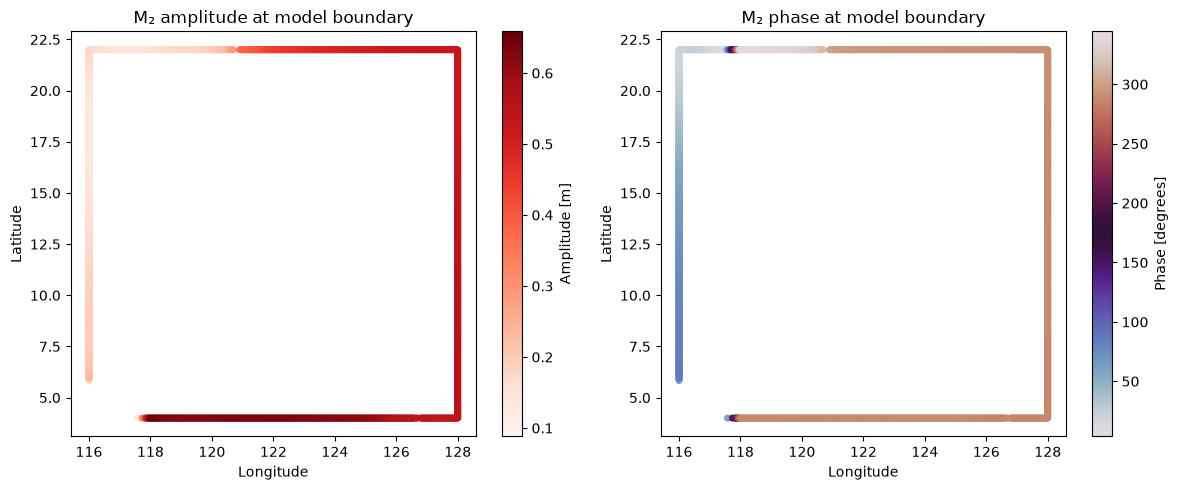

The amplitude plot shows where the tide is strongest at the boundary.
The phase plot shows timing — different colours mean high tide arrives
at different times along the boundary, which is essential for realistic flow.


In [7]:
m2 = constituents[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
sc = ax.scatter(m2.lon, m2.lat, c=m2.amplitude, s=15, cmap="Reds")
ax.set_title("M₂ amplitude at model boundary")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.colorbar(sc, ax=ax, label="Amplitude [m]")

ax = axes[1]
sc = ax.scatter(m2.lon, m2.lat, c=np.rad2deg(m2.phase), s=15, cmap="twilight")
ax.set_title("M₂ phase at model boundary")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.colorbar(sc, ax=ax, label="Phase [degrees]")

plt.tight_layout()
plt.show()
print("The amplitude plot shows where the tide is strongest at the boundary.")
print("The phase plot shows timing — different colours mean high tide arrives")
print("at different times along the boundary, which is essential for realistic flow.")

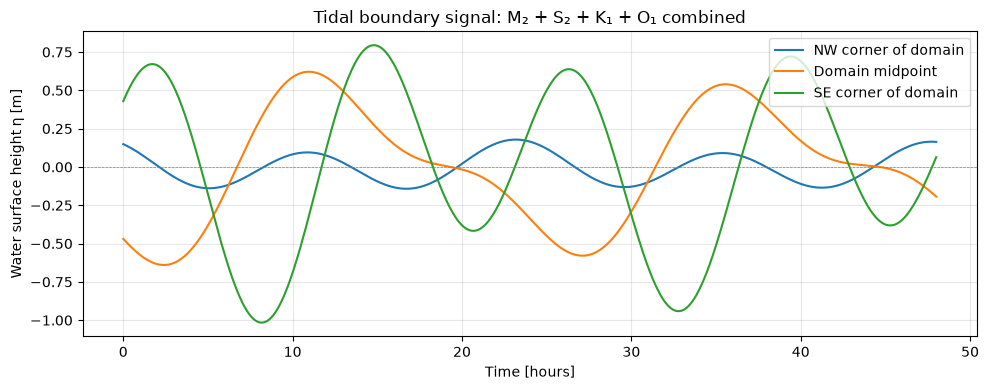

Notice the spring-neap cycle: large swings (~14 h in) are spring tides,
smaller swings are neap tides. This 14.8-day modulation comes from the
interference between M₂ and S₂ — like two musical notes beating together.


In [8]:
# Reconstruct the tidal signal — the orchestra playing all notes together
T_M2 = 2 * np.pi / ASTRO_FREQUENCIES["M2"]
t_hrs = np.linspace(0, 48, 500)
t_sec = t_hrs * 3600
eta_ts = tidal_bnd.evaluate(t_sec)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_hrs, eta_ts[:, 0], label="NW corner of domain", lw=1.5)
ax.plot(t_hrs, eta_ts[:, len(lon_bnd)//2], label="Domain midpoint", lw=1.5)
ax.plot(t_hrs, eta_ts[:, -1], label="SE corner of domain", lw=1.5)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.set_xlabel("Time [hours]")
ax.set_ylabel("Water surface height η [m]")
ax.set_title("Tidal boundary signal: M₂ + S₂ + K₁ + O₁ combined")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Notice the spring-neap cycle: large swings (~14 h in) are spring tides,")
print("smaller swings are neap tides. This 14.8-day modulation comes from the")
print("interference between M₂ and S₂ — like two musical notes beating together.")

---
## Part 7 — Time-Stepping: Marching the Ocean Forward

### The basic idea

The model starts at time zero with flat water and no currents.  Every few
seconds, it:

1.  **Sets the edge water levels** from the tidal boundary conditions
2.  **Updates the currents** — water flows from high to low, slowed by friction
3.  **Updates the water levels** — if water flowed into a cell, it rises

This is called **time-stepping**.  Each step is tiny (a few seconds), but
after millions of steps we have simulated weeks of ocean behaviour.

### An analogy: a dripping tap into a sink

Think of each cell as a bucket with holes in its sides.  Every second:
- You check how much water is in each neighbouring bucket
- Water flows through the holes from fuller buckets to emptier ones
- You update each bucket's new water level

The model does this for ~90 000 buckets, 8 times per second, for 15 simulated
days.  That's ~1 billion bucket updates — but a computer handles it in minutes.

### The forward-backward scheme

Our model uses a simple but effective time-stepping pattern called
**forward-backward**:

```
  Step n                          Step n+1
  ──────                          ────────
  ηⁿ, uⁿ, vⁿ  ──▶  uⁿ⁺¹  ──▶  vⁿ⁺¹  ──▶  ηⁿ⁺¹
                 (update u)   (update v)   (update η)
```

1.  **Update u** (east–west velocity) using current η and v
2.  **Update v** (north–south velocity) using current η and *new* u
3.  **Update η** (water height) using *new* u and v

This ordering is important — using the freshly updated u when computing v
improves stability.

### Semi-implicit bottom friction

Bottom friction is **stiff** — it gets very strong in shallow water.  If we
treated it explicitly, the model would blow up in cells shallower than a few
metres.

The trick: we treat friction **semi-implicitly**.  The friction force depends
on the *new* velocity, which we don't know yet, but we approximate it using
the *old* speed.  This keeps the model stable everywhere without requiring
tiny time steps.

In [9]:
from model.solver import ShallowWaterSolver
from model.utils import cfl_timestep

sim_cfg = cfg["simulation"]
solver = ShallowWaterSolver(
    grid,
    cd=sim_cfg.get("cd", 0.0025),
    ah=sim_cfg.get("ah", 0.0),
    advection=sim_cfg.get("advection", False),
    rho=sim_cfg.get("rho", 1025.0),
)
solver.set_open_boundary_eta(tidal_bnd)

dt = cfl_timestep(grid.dx, grid.dy, grid.h_max, safety=sim_cfg.get("cfl_safety", 0.5))
c_wave = np.sqrt(9.81 * grid.h_max)
dx_eff = 1.0 / np.sqrt(1.0/grid.dx**2 + 1.0/grid.dy**2)

print(f"Grid:          {grid.shape[0]} × {grid.shape[1]} cells  ({grid.mask.sum():,} wet)")
print(f"Spacing:       dx={grid.dx:.0f} m  dy={grid.dy:.0f} m")
print(f"Max depth:     {grid.h_max:.0f} m")
print(f"Wave speed:    c = √(g × h_max) = {c_wave:.0f} m/s = {c_wave*3.6:.0f} km/h")
print(f"Time step:     Δt = {dt:.2f} s  (2D CFL, safety factor {sim_cfg.get('cfl_safety', 0.5)})")
print(f"Steps per day: {86400/dt:,.0f}")

Grid:          1002 × 668 cells  (573,109 wet)
Spacing:       dx=1995 m  dy=1999 m
Max depth:     6000 m
Wave speed:    c = √(g × h_max) = 243 m/s = 873 km/h
Time step:     Δt = 2.91 s  (2D CFL, safety factor 0.5)
Steps per day: 29,689


---
## Part 8 — Stability: Why We Can't Just Run Faster

### The CFL condition (Courant–Friedrichs–Lewy)

Imagine you're taking a photo of a race car.  If your shutter speed is too
slow, the car moves many metres while the shutter is open and the photo is a
blur.  If the shutter is fast enough, the car barely moves and the photo is
sharp.

A hydrodynamic model has the same constraint.  A wave of information (a tide)
travels at speed $c = \sqrt{g \cdot h}$.  In one time step $\Delta t$, the
wave must travel **less than one grid cell**:

$$
c \cdot \Delta t < \Delta x
\quad\Longrightarrow\quad
\Delta t < \frac{\Delta x}{c}
$$

If this is violated, the model **goes unstable** — numbers explode to infinity
(NaN).  In 2D the condition is slightly tighter because waves can travel
diagonally.

### What determines the time step?

| Factor | Effect on Δt | Why |
|---|---|---|
| **Finer grid** (smaller Δx) | ↓ smaller Δt | Waves cross cells faster |
| **Deeper water** (larger h) | ↓ smaller Δt | Waves travel faster in deep water |
| **Higher safety factor** | ↓ smaller Δt | More conservative = safer |

For our 2 km Philippine grid with 5 800 m max depth:
- Wave speed = √(9.81 × 5 800) ≈ **238 m/s** (~850 km/h!)
- To cross a 2 km cell: 2 000 / 238 ≈ **8.4 seconds**
- With safety factor 0.5: Δt ≈ **2.9 seconds** → ~30 000 steps per day

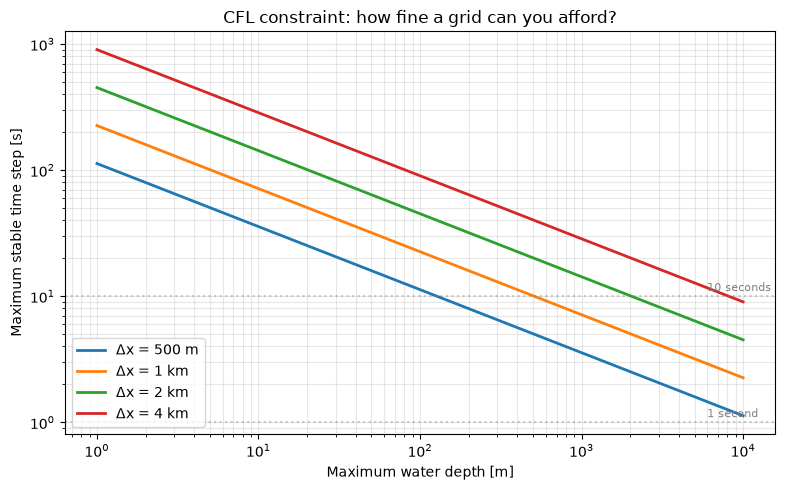

Key insight: deeper water → faster waves → smaller time step needed.
A 2 km grid in 6000 m water needs Δt ≈ 3 s; in 50 m water, Δt ≈ 30 s.


In [10]:
depths = np.logspace(0, 4, 100)
resolutions = [500, 1000, 2000, 4000]
labels = ["500 m", "1 km", "2 km", "4 km"]

fig, ax = plt.subplots(figsize=(8, 5))
for res, label in zip(resolutions, labels):
    c = np.sqrt(9.81 * depths)
    dx_eff = res / np.sqrt(2)
    dt_max = dx_eff / c
    ax.loglog(depths, dt_max, label=f"Δx = {label}", lw=2)

ax.axhline(1.0, color="gray", linestyle=":", alpha=0.4)
ax.axhline(10.0, color="gray", linestyle=":", alpha=0.4)
ax.text(6000, 1.1, "1 second", fontsize=8, color="gray")
ax.text(6000, 11, "10 seconds", fontsize=8, color="gray")
ax.set_xlabel("Maximum water depth [m]")
ax.set_ylabel("Maximum stable time step [s]")
ax.set_title("CFL constraint: how fine a grid can you afford?")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()
print("Key insight: deeper water → faster waves → smaller time step needed.")
print("A 2 km grid in 6000 m water needs Δt ≈ 3 s; in 50 m water, Δt ≈ 30 s.")

---
## Part 9 — Running the Model

Let's run a short simulation (~1 hour simulated) and watch the ocean wake up
from rest.  At time zero the water is flat everywhere — it takes a few hours
for the tidal signal from the boundaries to propagate into the interior.

Simulating 1.0 h = 1,237 steps at Δt = 2.91 s …


Done in 6.4 s wall-clock time  (194 steps/s)
Speed: 566× real time  (1 s wall = 566 s simulated)


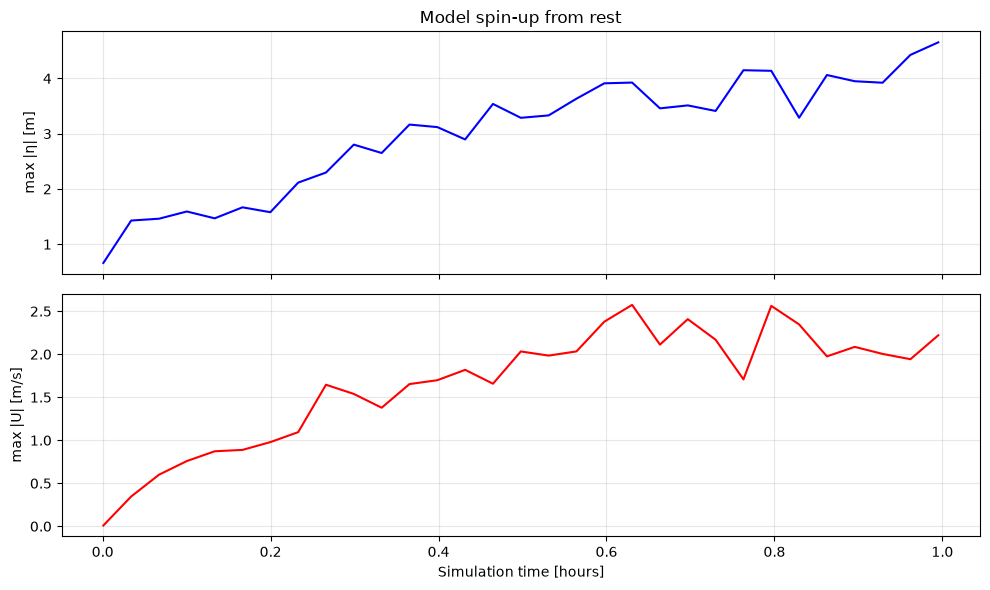

The water starts flat (η=0, U=0) and the tidal signal propagates
inward from the boundaries.  Oscillations grow as the domain fills.


In [11]:
import time

sim_hours = 1.0
n_steps = int(sim_hours * 3600 / dt)
snapshots = {"t": [], "eta": [], "u": [], "v": []}

print(f"Simulating {sim_hours} h = {n_steps:,} steps at Δt = {dt:.2f} s …")
t0 = time.monotonic()

save_every = max(1, n_steps // 30)
for step in range(n_steps):
    solver.step(dt)
    if step % save_every == 0:
        snapshots["t"].append(solver.time / 3600)
        snapshots["eta"].append(solver.eta.copy())
        snapshots["u"].append(solver.u.copy())
        snapshots["v"].append(solver.v.copy())

wall = time.monotonic() - t0
print(f"Done in {wall:.1f} s wall-clock time  ({n_steps/wall:.0f} steps/s)")
print(f"Speed: {sim_hours*3600/wall:.0f}× real time  (1 s wall = {sim_hours*3600/wall:.0f} s simulated)")

active = grid.mask
eta_max = [float(np.max(np.abs(s[active]))) for s in snapshots["eta"]]
u_max = [float(np.max(np.abs(s[grid.mask_u]))) for s in snapshots["u"]]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(snapshots["t"], eta_max, "b-", lw=1.5)
ax1.set_ylabel("max |η| [m]")
ax1.set_title("Model spin-up from rest")
ax1.grid(True, alpha=0.3)
ax2.plot(snapshots["t"], u_max, "r-", lw=1.5)
ax2.set_xlabel("Simulation time [hours]")
ax2.set_ylabel("max |U| [m/s]")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("The water starts flat (η=0, U=0) and the tidal signal propagates")
print("inward from the boundaries.  Oscillations grow as the domain fills.")

---
## Part 10 — Tidal Power: Where Is the Energy?

### How much power in a current?

A tidal turbine extracts energy from moving water, just as a wind turbine
extracts energy from moving air.  The power available per square metre of
flow area is:

$$
P = \frac{1}{2} \, \rho \, |\mathbf{U}|^3
$$

where $\rho$ = 1 025 kg/m³ (seawater density) and $|\mathbf{U}|$ = current speed.

**The crucial $|\mathbf{U}|^3$:** doubling the current speed gives **8×** the
power.  This is why tidal energy developers obsess over finding the fastest
flows — a site with 3 m/s currents has 27× the power density of a site with
1 m/s currents.

| Current speed | Power density | Viable for turbines? |
|---|---|---|
| 0.5 m/s | 64 W/m² | Too slow |
| 1.0 m/s | 513 W/m² | Marginal |
| 2.0 m/s | 4 100 W/m² | Good |
| 3.0 m/s | 13 838 W/m² | Excellent |
| 4.0 m/s | 32 800 W/m² | Exceptional (rare) |

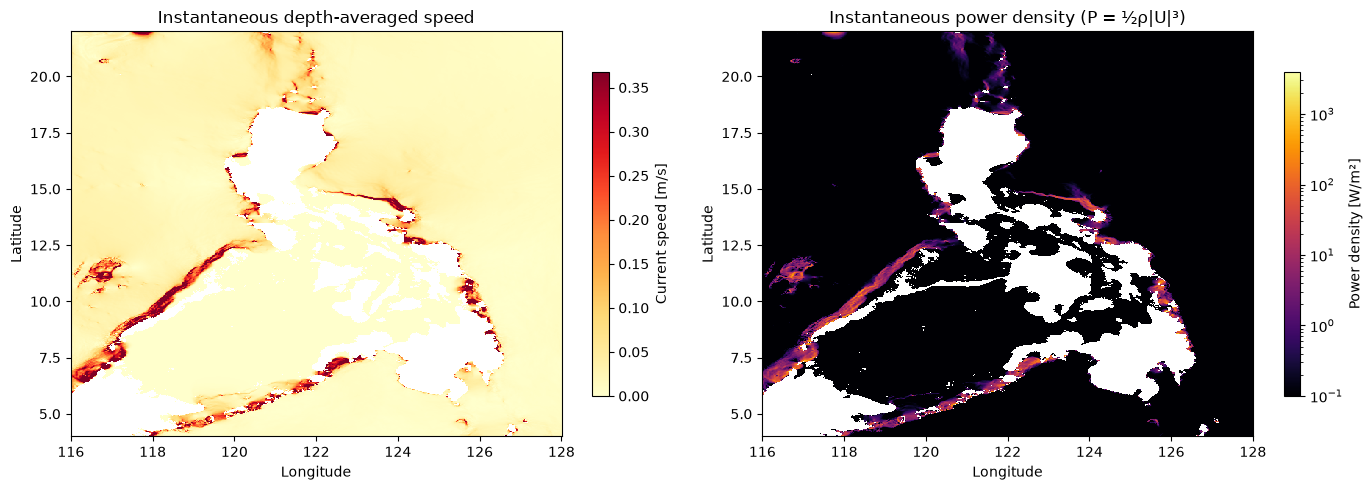

The log scale on the power plot reveals that power varies over 5+ orders
of magnitude.  The hottest spots are in narrow channels between islands.


In [12]:
from model.utils import speed, power_density

eta_final = solver.eta.copy()
spd = speed(solver.u, solver.v)
pwr = power_density(solver.u, solver.v, rho=1025.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

d_plot = np.where(grid.mask, spd, np.nan)
pc = axes[0].pcolormesh(grid.lon, grid.lat, d_plot, cmap="YlOrRd", shading="auto",
                        vmin=0, vmax=np.nanpercentile(d_plot, 99))
plt.colorbar(pc, ax=axes[0], label="Current speed [m/s]", shrink=0.8)
axes[0].set_title("Instantaneous depth-averaged speed")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

p_plot = np.where(grid.mask, pwr, np.nan)
pc = axes[1].pcolormesh(grid.lon, grid.lat, p_plot, cmap="inferno", shading="auto",
                        norm=mcolors.LogNorm(vmin=0.1, vmax=np.nanmax(p_plot)))
plt.colorbar(pc, ax=axes[1], label="Power density [W/m²]", shrink=0.8)
axes[1].set_title("Instantaneous power density (P = ½ρ|U|³)")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()
print("The log scale on the power plot reveals that power varies over 5+ orders")
print("of magnitude.  The hottest spots are in narrow channels between islands.")

### Mean power and hotspot identification

Instantaneous power fluctuates with the tide.  What matters for energy
planning is the **time-averaged** power over at least one tidal cycle.
Cells where the mean power density exceeds a threshold (default 200 W/m²)
are flagged as **hotspots** and exported for further analysis.

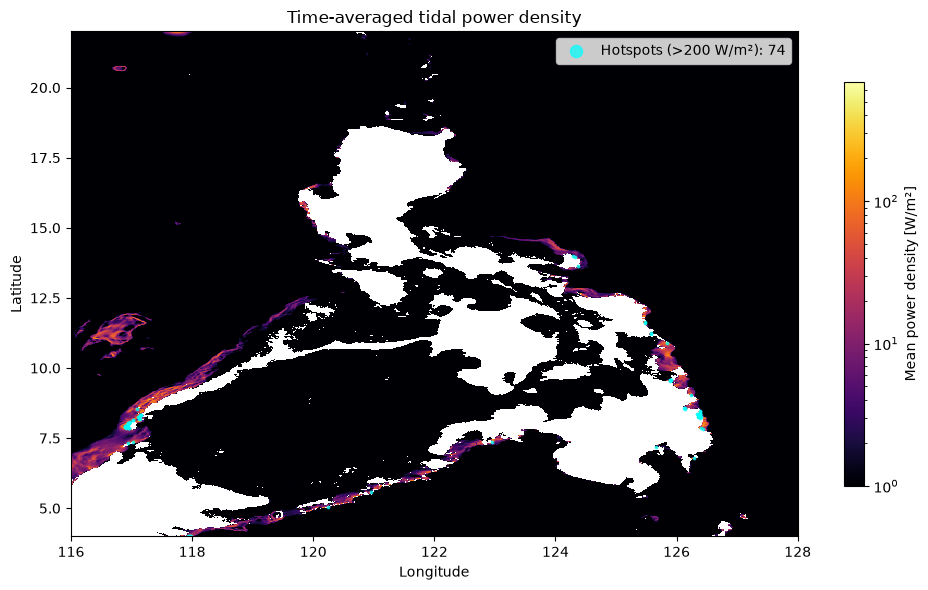

Mean power density: 0.5 W/m²
Max  power density: 688.5 W/m²
95th percentile:    0.2 W/m²
Hotspots (> 200 W/m²): 74 cells  (0.01% of wet area)


In [13]:
power_hist = np.stack([
    power_density(snapshots["u"][k], snapshots["v"][k], rho=1025.0)
    for k in range(len(snapshots["t"]))
])
power_mean = np.mean(power_hist, axis=0)

threshold = cfg["output"].get("hotspot_threshold", 200.0)
hotspots = power_mean >= threshold

fig, ax = plt.subplots(figsize=(10, 6))
pm = np.where(grid.mask, power_mean, np.nan)
pc = ax.pcolormesh(grid.lon, grid.lat, pm, cmap="inferno", shading="auto",
                   norm=mcolors.LogNorm(vmin=1, vmax=np.nanmax(pm)))
cb = plt.colorbar(pc, ax=ax, label="Mean power density [W/m²]", shrink=0.8)

h_lon = grid.lon[hotspots]
h_lat = grid.lat[hotspots]
ax.scatter(h_lon, h_lat, s=3, c="cyan", marker="o", alpha=0.7,
           label=f"Hotspots (>{threshold:.0f} W/m²): {hotspots.sum():,}")

ax.set_title("Time-averaged tidal power density")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

p_flat = power_mean[grid.mask]
print(f"Mean power density: {np.mean(p_flat):.1f} W/m²")
print(f"Max  power density: {np.max(p_flat):.1f} W/m²")
print(f"95th percentile:    {np.percentile(p_flat, 95):.1f} W/m²")
print(f"Hotspots (> {threshold:.0f} W/m²): {hotspots.sum():,} cells  "
      f"({hotspots.sum()/grid.mask.sum()*100:.2f}% of wet area)")

---
## Part 11 — What the Model Can and Cannot Do

### This model is good for:

- **Screening** — finding which regions have enough tidal current to be worth
  studying further
- **Relative comparisons** — channel A vs. channel B for siting priority
- **First-order energy estimates** — approximate power available per unit area
- **Understanding tidal dynamics** — how tides propagate through the archipelago

### This model is NOT suitable for:

- **Detailed turbine design** — you need a 3D model with turbulence for that
- **Operational forecasting** — this is a screening tool, not a real-time system
- **Sediment transport** — no sediment module is included
- **Storm surge / wind-driven effects** — wind and atmospheric pressure are ignored

### Key simplifications we made

| Simplification | Impact |
|---|---|
| 2D (depth-averaged) | Misses vertical structure of flow |
| No wind forcing | Misses storm-driven currents |
| No density effects | Assumes uniform temperature/salinity |
| Rigid lid on land | No wetting/drying of intertidal zones |
| Coarse resolution (2 km) | Misses sub-grid channels and headlands |

---
## Key Parameters Reference

All configurable in `src/model/config.yaml`:

| Parameter | Key | Default | What it does |
|---|---|---|---|
| Grid resolution | `domain.resolution_km` | 2.0 | Cell size — smaller = more detail, slower |
| Minimum depth | `bathymetry.min_depth` | 2.0 m | Cells shallower than this are treated as dry |
| Maximum depth | `bathymetry.max_depth` | 6000 m | Caps unrealistic depths |
| Land shapefile | `bathymetry.land_shapefile` | GADM .shp | Defines coastline |
| CFL safety | `simulation.cfl_safety` | 0.5 | Lower = more stable but slower (0.2–0.8) |
| Bottom drag | `simulation.cd` | 0.0025 | How much the seafloor slows the flow |
| Eddy viscosity | `simulation.ah` | 0.0 | Horizontal turbulent mixing (usually off) |
| Duration | `simulation.duration_days` | 15 | One complete spring-neap cycle |
| Tidal source | `tidal_forcing.source` | got | Which global atlas to use |
| Constituents | `tidal_forcing.constituents` | [M2,S2,K1,O1] | Which tidal harmonics to include |
| Hotspot threshold | `output.hotspot_threshold` | 200 W/m² | Power level for hotspot export |

---

## Next Steps

- **Run the full 15-day simulation:** `python -m src.model.run`
- **Try a different tidal atlas:** change `tidal_forcing.source` to `fes2014` or `tpxo9`
- **Increase resolution:** set `domain.resolution_km: 1.0` for finer detail
- **Visualise results:** open the web map at `http://localhost:5000`
- **Read the model code:** start with `src/model/solver.py` to see the time-stepping